# 🇬🇲 Understanding Child Malnutrition in The Gambia
### A Data Story from the MICS6 National Household Survey

**Author:** [Muhammad Taqui]  
**Date:** August 2026  
**Data Source:** UNICEF Multiple Indicator Cluster Survey (MICS6), The Gambia — 2018,
via [mics.unicef.org/surveys](http://mics.unicef.org/surveys), The Gambia Bureau of Statistics (GBoS) & UNICEF

---

## 📌 Problem Statement

Child malnutrition remains one of the most persistent threats to child survival and development in The Gambia.
Despite national and international efforts, thousands of children under five still suffer from stunting, wasting,
and underweight — conditions with lifelong consequences for health, learning, and economic potential.

This project uses nationally representative MICS6 data to explore **where malnutrition is concentrated,
who is most affected, and what factors are associated with it** — turning raw survey data into evidence
that can inform UNICEF's child health and nutrition programming in The Gambia.

---

## 🎯 Project Summary (STAR)

**Situation:** The Gambia continues to face high rates of child malnutrition, but disaggregated,
accessible analysis of *who* is most affected is not always readily available to program teams.

**Task:** Analyze the MICS6 under-5 children's dataset to quantify stunting, wasting, and underweight,
and identify key disparities by region, wealth, sex, and maternal education.

**Action:** Cleaned and applied sample weights to the official MICS6 dataset, calculated WHO-standard
nutrition indicators, built visual breakdowns by demographic/geographic subgroups, and used an AI-assisted
layer to auto-generate plain-language insight summaries.

**Result:** A reproducible, documented notebook that surfaces actionable nutrition insights —
demonstrating how AI and data science tools can support evidence-based child welfare decisions in The Gambia.

---

## 🔧 Step 1: Load the Data

Before any analysis, we need to read the raw SPSS (`.sav`) file into Python. MICS datasets are distributed
in SPSS format, so we use `pyreadstat`, which reads both the data **and** the variable/value labels
(e.g. converting coded region numbers into readable names). This preserves the official metadata provided
by GBoS/UNICEF rather than guessing at what each code means.

We also do a first-look inspection — checking the shape of the dataset and a few key variables — to confirm
the data loaded correctly before we start cleaning.

In [3]:
# Install the library needed to read SPSS (.sav) files
!pip install pyreadstat -q

import pandas as pd
import pyreadstat

# Load the under-5 children's dataset along with its metadata (variable labels, value labels)
df, meta = pyreadstat.read_sav("ch.sav")

# Quick sanity check
print("Dataset shape:", df.shape)
print("\nSample of key nutrition-related columns:")
df[["HH6", "HH7", "HL4", "windex5", "chweight", "HAZ2", "WAZ2", "WHZ2"]].head()

Dataset shape: (10156, 465)

Sample of key nutrition-related columns:


,HH6,HH7,HL4,windex5,chweight,HAZ2,WAZ2,WHZ2
0,1.0,1.0,1.0,5.0,0.20211,0.57,1.57,1.70
1,1.0,1.0,1.0,5.0,0.20211,-1.06,-1.08,-0.81
2,1.0,1.0,2.0,5.0,0.20211,99.99,-0.81,99.99
3,1.0,1.0,1.0,4.0,0.20211,-2.04,-1.92,-1.21
4,1.0,1.0,1.0,5.0,0.20211,-0.92,-0.07,0.65


## 🧹 Step 2: Clean the Data

Raw survey data always needs cleaning before analysis. Two things stand out:

1. **Special missing-value codes:** MICS uses `99.99` (and similar) to flag implausible or missing
   anthropometric measurements (e.g. child couldn't be measured properly). If we don't remove these,
   they'll badly distort our averages.
2. **Biologically implausible values:** WHO recommends excluding z-scores outside a plausible range
   (roughly -6 to +6) as likely measurement/data-entry errors — this is standard practice in nutrition
   surveys, not something we're deciding arbitrarily.

We also select only the columns we actually need for this project, so the dataset is easier to work with
and the notebook stays focused on the nutrition story rather than all 465 variables.

In [4]:
# Select only the variables relevant to our nutrition story
cols = [
    "HH6", "HH7", "HL4", "windex5", "melevel", "chweight",
    "HAZ2", "WAZ2", "WHZ2", "HAZFLAG", "WAZFLAG", "WHZFLAG",
    "BD2", "BD3", "CAGE"
]

nutrition_df = df[cols].copy()

# Replace MICS missing-value codes (99.99) with proper NaN
for col in ["HAZ2", "WAZ2", "WHZ2"]:
    nutrition_df[col] = nutrition_df[col].replace(99.99, pd.NA)

# Drop biologically implausible z-scores (WHO standard: keep -6 to +6)
nutrition_df = nutrition_df[
    (nutrition_df["HAZ2"].between(-6, 6)) &
    (nutrition_df["WAZ2"].between(-6, 6)) &
    (nutrition_df["WHZ2"].between(-6, 6))
]

print("Rows before cleaning:", df.shape[0])
print("Rows after cleaning:", nutrition_df.shape[0])
nutrition_df.head()

Rows before cleaning: 10156
Rows after cleaning: 9696


,HH6,HH7,HL4,windex5,melevel,chweight,HAZ2,WAZ2,WHZ2,HAZFLAG,WAZFLAG,WHZFLAG,BD2,BD3,CAGE
0,1.0,1.0,1.0,5.0,2.0,0.20211,0.57,1.57,1.7,0.0,0.0,0.0,NaN,NaN,59.0
1,1.0,1.0,1.0,5.0,2.0,0.20211,-1.06,-1.08,-0.81,0.0,0.0,0.0,1.0,1.0,16.0
3,1.0,1.0,1.0,4.0,0.0,0.20211,-2.04,-1.92,-1.21,0.0,0.0,0.0,NaN,NaN,37.0
4,1.0,1.0,1.0,5.0,2.0,0.20211,-0.92,-0.07,0.65,0.0,0.0,0.0,NaN,NaN,37.0
5,1.0,1.0,2.0,5.0,2.0,0.20211,-0.35,-0.82,-0.98,0.0,0.0,0.0,1.0,2.0,26.0


## 📊 Step 3: Create Nutrition Indicator Flags

The WHO defines child malnutrition using standard z-score cutoffs:

- **Stunting** (chronic malnutrition): Height-for-age z-score (HAZ2) < -2
- **Underweight**: Weight-for-age z-score (WAZ2) < -2
- **Wasting** (acute malnutrition): Weight-for-height z-score (WHZ2) < -2
- **Severe** versions of each use a cutoff of < -3

Converting continuous z-scores into these yes/no flags lets us calculate prevalence rates
(e.g. "% of children stunted") the same way UNICEF and GBoS report them in official statistics —
so our numbers are comparable to the published MICS6 report.

In [5]:
# Create binary indicator flags using WHO standard cutoffs
nutrition_df["stunted"] = (nutrition_df["HAZ2"] < -2).astype(int)
nutrition_df["severely_stunted"] = (nutrition_df["HAZ2"] < -3).astype(int)

nutrition_df["underweight"] = (nutrition_df["WAZ2"] < -2).astype(int)
nutrition_df["severely_underweight"] = (nutrition_df["WAZ2"] < -3).astype(int)

nutrition_df["wasted"] = (nutrition_df["WHZ2"] < -2).astype(int)
nutrition_df["severely_wasted"] = (nutrition_df["WHZ2"] < -3).astype(int)

# National prevalence (weighted, using chweight for correct estimates)
def weighted_rate(flag_col, weight_col="chweight"):
    return (nutrition_df[flag_col] * nutrition_df[weight_col]).sum() / nutrition_df[weight_col].sum() * 100

print("National Prevalence (weighted %):")
print(f"Stunting:      {weighted_rate('stunted'):.1f}%")
print(f"Underweight:   {weighted_rate('underweight'):.1f}%")
print(f"Wasting:       {weighted_rate('wasted'):.1f}%")

National Prevalence (weighted %):
Stunting:      18.9%
Underweight:   13.8%
Wasting:       6.2%


## 🗺️ Step 4: Who Is Most Affected? — Breaking Down by Region, Wealth, and Sex

National averages hide inequality. UNICEF's mandate is about reaching the *most vulnerable* children —
so the real story is in the disparities: which regions (LGAs), wealth groups, and sexes carry the
heaviest burden of malnutrition.

Here we recalculate stunting prevalence (our headline indicator) broken down by:
- **HH7** – Local Government Area (region)
- **windex5** – Household wealth quintile (1 = poorest, 5 = richest)
- **HL4** – Sex of child (1 = male, 2 = female)

This turns one national number into an actionable map of where interventions matter most.

/tmp/ipykernel_1972/2193099077.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col).apply(wavg).sort_values(ascending=False)
/tmp/ipykernel_1972/2193099077.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col).apply(wavg).sort_values(ascending=False)
/tmp/ipykernel_1972/2193099077.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping

Stunting by LGA (%):
 HH7
6.0    26.5
7.0    24.3
5.0    20.8
8.0    19.5
4.0    19.0
3.0    17.7
1.0    16.7
2.0    14.5
dtype: float64

Stunting by wealth quintile (%):
 windex5
1.0    24.0
2.0    21.5
3.0    18.9
4.0    14.3
5.0    13.0
dtype: float64

Stunting by sex (%):
 HL4
1.0    21.5
2.0    16.3
dtype: float64


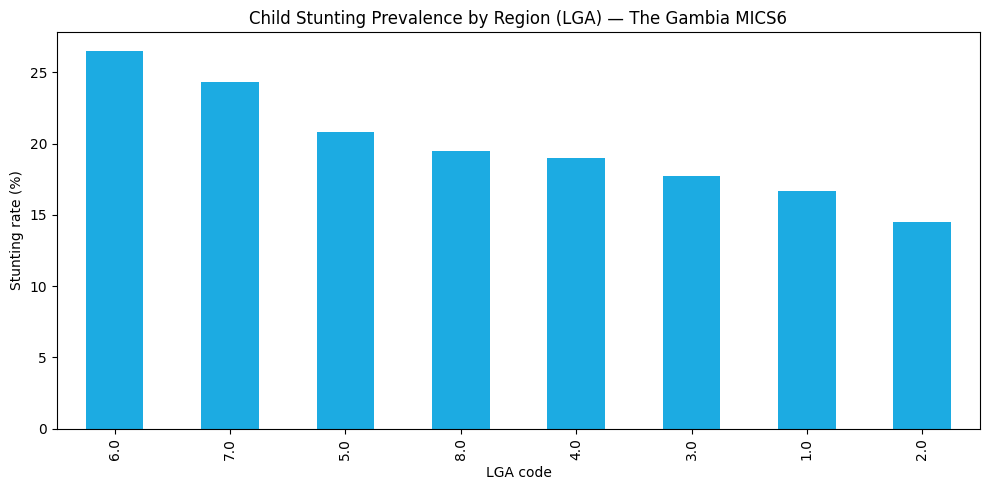

In [6]:
import matplotlib.pyplot as plt

# Weighted stunting rate by subgroup, using a reusable helper
def weighted_group_rate(df, group_col, flag_col="stunted", weight_col="chweight"):
    def wavg(x):
        return (x[flag_col] * x[weight_col]).sum() / x[weight_col].sum() * 100
    return df.groupby(group_col).apply(wavg).sort_values(ascending=False)

# --- By region (LGA) ---
by_region = weighted_group_rate(nutrition_df, "HH7")
print("Stunting by LGA (%):\n", by_region.round(1))

# --- By wealth quintile ---
by_wealth = weighted_group_rate(nutrition_df, "windex5")
print("\nStunting by wealth quintile (%):\n", by_wealth.round(1))

# --- By sex ---
by_sex = weighted_group_rate(nutrition_df, "HL4")
print("\nStunting by sex (%):\n", by_sex.round(1))

# Quick visual: stunting by region
plt.figure(figsize=(10,5))
by_region.plot(kind="bar", color="#1CABE2")  # UNICEF blue
plt.title("Child Stunting Prevalence by Region (LGA) — The Gambia MICS6")
plt.ylabel("Stunting rate (%)")
plt.xlabel("LGA code")
plt.tight_layout()
plt.show()

## 🏷️ Step 5: Naming the Regions

LGA codes (1–8) aren't meaningful on their own. The MICS6 metadata (`meta.variable_value_labels`) stores
the official label for each code — the actual district/LGA names used by GBoS. Mapping these in makes
the chart interpretable to a non-technical audience (like a UNICEF programme officer), not just to us.

We also switch to `.agg()` instead of `.apply()` to avoid a pandas deprecation warning and make the
weighted-average calculation more explicit and future-proof.

LGA code -> name mapping:
1.0 -> Banjul
2.0 -> Kanifing
3.0 -> Brikama
4.0 -> Mansakonko
5.0 -> Kerewan
6.0 -> Kuntaur
7.0 -> Janjanbureh
8.0 -> Basse


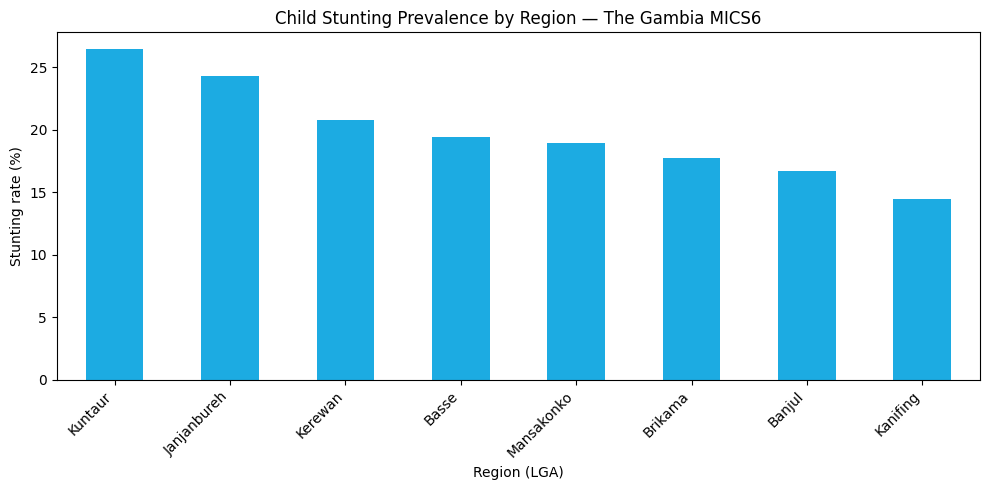

In [9]:
# Look up the real LGA names from the SPSS metadata
lga_labels = meta.variable_value_labels.get("HH7", {})
print("LGA code -> name mapping:")
for code, name in lga_labels.items():
    print(code, "->", name)

def weighted_group_rate(df, group_col, flag_col="stunted", weight_col="chweight"):
    g = df.groupby(group_col)
    weighted_sum = g.apply(lambda x: (x[flag_col] * x[weight_col]).sum(), include_groups=False)
    total_weight = g[weight_col].sum()
    return (weighted_sum / total_weight * 100).sort_values(ascending=False)

by_region = weighted_group_rate(nutrition_df, "HH7")

# Map codes to names for the chart
lga_labels = meta.variable_value_labels.get("HH7", {})
by_region_named = by_region.rename(index=lga_labels)

plt.figure(figsize=(10,5))
by_region_named.plot(kind="bar", color="#1CABE2")
plt.title("Child Stunting Prevalence by Region — The Gambia MICS6")
plt.ylabel("Stunting rate (%)")
plt.xlabel("Region (LGA)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 💰 Step 6: Wealth and Sex Disparities

Region tells us *where*. Wealth and sex tell us *who*. Here we visualize both:

- **Wealth quintile:** confirms whether malnutrition is concentrated among poorer households —
  a critical equity question for programme targeting.
- **Sex:** checks whether boys and girls are affected differently, which MICS6 data already hints at.

Together with the regional chart, these three views form the core "who is most affected" story.

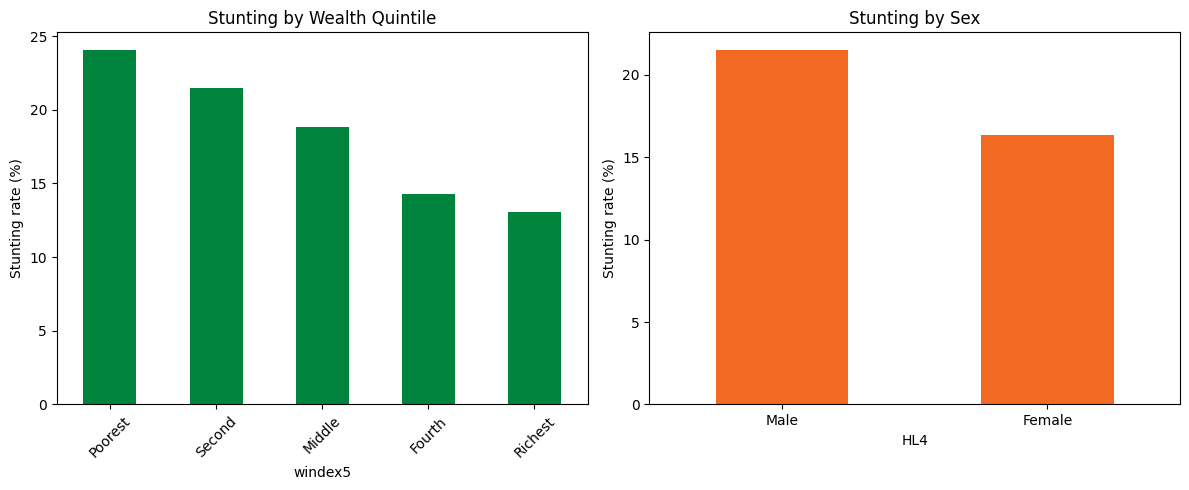

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Wealth quintile chart
by_wealth = weighted_group_rate(nutrition_df, "windex5")
wealth_labels = {1.0: "Poorest", 2.0: "Second", 3.0: "Middle", 4.0: "Fourth", 5.0: "Richest"}
by_wealth.rename(index=wealth_labels).plot(kind="bar", ax=axes[0], color="#00833D")  # UNICEF green
axes[0].set_title("Stunting by Wealth Quintile")
axes[0].set_ylabel("Stunting rate (%)")
axes[0].tick_params(axis='x', rotation=45)

# Sex chart
by_sex = weighted_group_rate(nutrition_df, "HL4")
sex_labels = {1.0: "Male", 2.0: "Female"}
by_sex.rename(index=sex_labels).plot(kind="bar", ax=axes[1], color="#F26A21")  # UNICEF orange
axes[1].set_title("Stunting by Sex")
axes[1].set_ylabel("Stunting rate (%)")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 📝 Step 7: What the Data Tells Us

Three consistent patterns emerge from the MICS6 data:

1. **Geography matters.** Stunting nearly doubles between the best-performing region (Kanifing, 14.5%)
   and the worst (Kuntaur, 26.5%). The four rural/upriver LGAs — Kuntaur, Janjanbureh, Kerewan, and Basse —
   all sit above the national average (18.9%), while urbanized Kanifing and Banjul sit well below it.

2. **Poverty is strongly linked to stunting.** Children in the poorest households are stunted at nearly
   **double** the rate of children in the richest (24.0% vs 13.0%) — a clear, consistent gradient across
   all five wealth quintiles.

3. **Boys are more affected than girls.** Male children show a stunting rate of 21.5% versus 16.3% for
   females — a gap consistent with global patterns often seen in early childhood malnutrition research.

**Programmatic implication:** These findings suggest nutrition interventions in The Gambia would have the
highest impact if prioritized in Kuntaur, Janjanbureh, Kerewan, and Basse, and targeted at the poorest
households — rather than applying a uniform national approach.

## 🤖 Step 8: AI-Assisted Insight Generation

So far, every insight above was written by us after manually reading the numbers. In a real UNICEF
programme setting, teams often need **fast, plain-language summaries** of statistical findings — for
briefs, donor reports, or non-technical stakeholders — without waiting for an analyst to write them up.

Here we use the GROQ FREE API to automatically generate a short, plain-language narrative summary
directly from our computed statistics. This demonstrates how AI can be layered on top of traditional data
analysis to speed up reporting — a small, responsible use of generative AI where **the AI only summarizes
numbers we've already computed and verified ourselves**, rather than generating or inventing any data.

**Note on responsible AI use:** All underlying statistics are computed directly from the official,
anonymized MICS6 dataset using standard weighting and WHO methodology. The AI step below only rephrases
these verified numbers into prose — it does not access raw respondent data, and no personally identifiable
information is involved at any stage.

In [12]:
!pip install openai -q

from openai import OpenAI
from google.colab import userdata

# Store your Groq API key in Colab's Secrets (key icon on the left sidebar), named GROQ_API_KEY
client = OpenAI(
    api_key=userdata.get("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1"
)

# Package our verified findings into a structured prompt
findings_summary = f"""
National child malnutrition statistics for The Gambia (MICS6, weighted):
- Stunting: 18.9%
- Underweight: 13.8%
- Wasting: 6.2%

Stunting by region (LGA), highest to lowest:
{by_region_named.round(1).to_string()}

Stunting by wealth quintile:
{by_wealth.rename(index=wealth_labels).round(1).to_string()}

Stunting by sex:
{by_sex.rename(index=sex_labels).round(1).to_string()}
"""

response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    max_tokens=400,
    messages=[{
        "role": "user",
        "content": f"""You are helping a UNICEF programme team interpret child nutrition survey findings.
Based ONLY on the statistics below, write a concise (150-200 word) plain-language summary suitable for a
non-technical programme brief. Highlight the most actionable disparities. Do not invent any numbers not
provided.

{findings_summary}"""
    }]
)

from IPython.display import Markdown, display

ai_summary = response.choices[0].message.content
display(Markdown(f"### 🧠 AI-Generated Programme Brief\n\n{ai_summary}"))

### 🧠 AI-Generated Programme Brief

The latest child nutrition survey in The Gambia reveals concerning levels of malnutrition among children. Nearly 19% of children are stunted, 14% are underweight, and 6% are wasted. Regional disparities in stunting are notable, with Kuntaur and Janjanbureh having the highest rates, at 26.5% and 24.3% respectively. Additionally, stunting affects more boys (21.5%) than girls (16.3%). The survey also highlights wealth-related disparities, with children from the poorest households experiencing stunting at a rate of 24%, compared to 13% among the richest. These findings suggest that targeted interventions in regions like Kuntaur and Janjanbureh, as well as programs addressing poverty and gender disparities, could help reduce child malnutrition in The Gambia. Addressing these actionable disparities can help improve the overall nutrition and well-being of children in the country.

## ✅ Conclusion & Next Steps

This project transformed a raw, 465-variable national survey file into a clear, actionable child
nutrition story for The Gambia — combining verified statistical analysis with an AI-assisted
summarization layer for fast, non-technical reporting.

### Key Takeaways
- **18.9%** of Gambian children under 5 are stunted, **13.8%** underweight, **6.2%** wasted (nationally weighted estimates)
- **Geography matters:** Kuntaur (26.5%) and Janjanbureh (24.3%) have nearly double the stunting rate of Kanifing (14.5%)
- **Poverty matters:** stunting is almost 2x higher in the poorest households vs. the richest (24.0% vs 13.0%)
- **Sex matters:** boys are more affected than girls (21.5% vs 16.3%)

### Recommended Next Steps
1. Prioritize nutrition programming in Kuntaur, Janjanbureh, Kerewan, and Basse
2. Layer wealth-targeting into intervention design, not just geographic targeting
3. Investigate the sex-based disparity further — possible drivers include feeding practices, illness patterns, or reporting differences
4. Extend this analysis to wasting and underweight breakdowns, and to trends over time using earlier MICS rounds

### Responsible AI Note
The AI component in this notebook was used strictly to **summarize pre-verified statistics** computed
directly from official, anonymized MICS6 data — not to generate, infer, or alter any underlying figures.
This reflects a responsible, transparent approach to applying generative AI in evidence-based development work.

---

*Data source: UNICEF/GBoS Multiple Indicator Cluster Survey 6 (MICS6), The Gambia.
Analysis and this notebook prepared independently for demonstration/portfolio purposes.*